# **STATS 503, Group Work Assignment 6: Splines and GAMs**

**Instructions:** During lab section, and afterward as necessary, you will collaborate in two-person teams (assigned by the GSI) to complete the problems that are interspersed below. The GSI will help individual teams encountering difficulty, make announcements addressing common issues, and help ensure progress for all teams. **During lab, feel free to flag down your GSI to ask questions at any point!** Upon completion, one member of the team should submit their team's work through Canvas as html.

**credits:** Paolo Borello, adapted from notes from Gabriel Patron.

## Requirements

For this lab we will need to install the `pygam` library.

In [4]:
!pip install pygam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.9/217.9 kB 4.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.6/29.6 MB 19.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pygam import LinearGAM, LogisticGAM, s, f

## `sklearn` [Pipelines](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)

''A sequence of data transformers with an optional final predictor.  
Pipeline allows you to sequentially apply a list of transformers to preprocess the data and, if desired, conclude the sequence with a final predictor for predictive modeling.  
Intermediate steps of the pipeline must be transformers, that is, they must implement fit and transform methods. The final estimator only needs to implement fit. The transformers in the pipeline can be cached using memory argument.  
The purpose of the pipeline is to assemble several steps that can be cross-validated together while setting different parameters.''

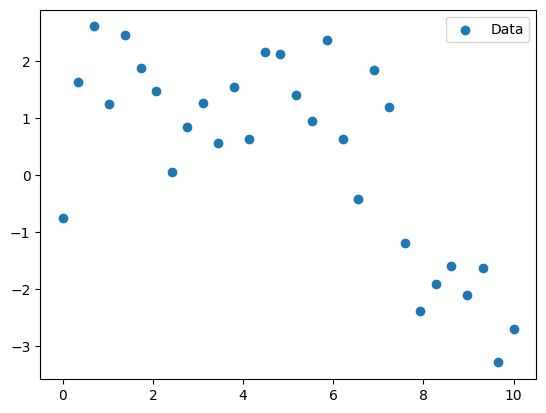

In [3]:
# Re-defining the data
np.random.seed(100)
x = np.linspace(0, 10, 30)
y =2 *  np.sin(0.5 * x) + np.cos(x) + np.random.randn(30)
X = x.reshape(-1, 1)  # Reshaping x for the models

# scatter plot of data
plt.scatter(X, y, label='Data')
plt.legend()
plt.show()

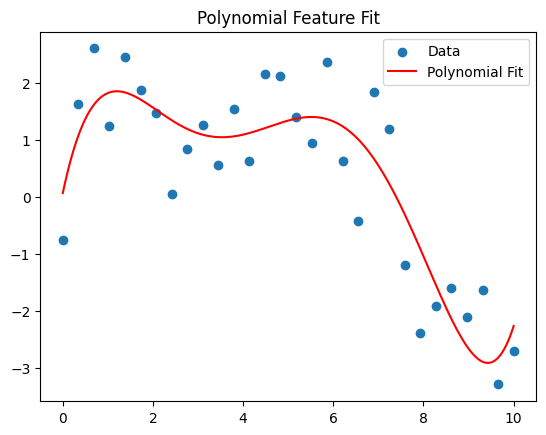

In [5]:
# Defining the pipeline with polynomial features
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=5)),
    ('scaling', StandardScaler()),
    ('linear_regression', LinearRegression())
])

# Fitting the model
poly_pipeline.fit(X, y)
# Predicting over the input range
X_test = np.linspace(0, 10, 200).reshape(-1, 1)
y_poly_pred = poly_pipeline.predict(X_test)

plt.scatter(X, y, label='Data')
plt.plot(X_test, y_poly_pred, label='Polynomial Fit', color='red')
plt.title('Polynomial Feature Fit')
plt.legend()
plt.show()

Let's check what's inside a `Pipeline` object

In [ ]:
poly_pipeline

Pipeline(steps=[('poly', PolynomialFeatures(degree=5)),
                ('scaling', StandardScaler()),
                ('linear_regression', LinearRegression())])

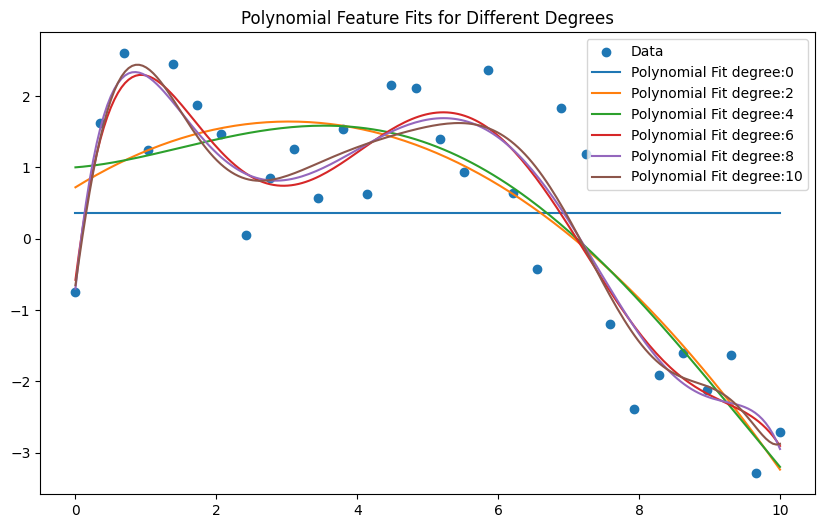

In [ ]:
degrees = range(0,12,2)

plt.figure(figsize=[10,6])
plt.scatter(X, y, label="Data")

for degree in degrees:
  poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('scaling', StandardScaler()),
    ('linear_regression', LinearRegression())
  ])

  # Fitting the model
  poly_pipeline.fit(X, y)
  # Predicting over the input range
  X_test = np.linspace(0, 10, 200).reshape(-1, 1)
  y_poly_pred = poly_pipeline.predict(X_test)


  # Plotting
  plt.plot(X_test, y_poly_pred, label=f'Polynomial Fit degree:{degree}')

plt.title("Polynomial Feature Fits for Different Degrees")
plt.legend()
plt.show()

## Cubic [Splines](https://en.wikipedia.org/wiki/Spline_(mathematics))

Consider a simple setup where we have data $\{(x_i,y_i)\}_{i=1}^n$, and $x_i\in \mathbb{R}^1$. We want to model the non-linear relationship between $y$ and $x$. Cubic spline is a method that fits a piece-wise cubic polynomial on contiguous intervals of $x$. Suppose that the minimum and maximum of all $x_i$ are $\xi_0,\xi_{K+1}$, respectively. There are $K$ knots in between that serve as the endpoints of the $K+1$ intervals of $x$: $\xi_1 < \xi_2 < \dots < \xi_K$. On every interval $[\xi_{k-1}, \xi_{k}]$ we fit a cubic polynomial $s_k(x)$ for $y$. Additionally, on each of the knot, we constrain that:

- Continuity: $s_k(\xi_{k}) = s_{k+1}(\xi_{k})$
- First-order continuity: $s_k^{\prime}(\xi_{k}) = s_{k+1}^{\prime}(\xi_{k})$
- Second-order continuity: $s_k^{\prime\prime}(\xi_{k}) = s_{k+1}^{\prime\prime}(\xi_{k})$

On every of the $K+1$ intervals, we have a cubic polynomial with 4 parameters, but on every of the $K$ knots we have the 3 constraints above. In aggregate, we have $4(K+1)−3K=K+4$ free parameters for cubic spline.

$$
s(x) = \beta_0 h_0(x) + \beta_1 h_1(x) + \dots + \beta_{K+3} h_{K+3}(x)
$$

where $h_{j}(x) = x^{j}, j = 0, 1, 2, 3$, and $h_{3+l}(x) = (x-\xi_l)_{+}^3, l=1,2,\dots,K$.

Documentation: [Spline Transformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html)

**So how many knots?**

In general, it turns out that the optimal number of knots is data dependent, and the rule-of-thumb of choosing knot location is to put more knots in the interval where function is varying a lot, and put fewer knots in the interval where the function is very smooth and can be approximated well by very few cubic polynomial. In practice, this requires you to do **exploratory data analysis**! A spline method with automatic knot selection called *smoothing spline* in the next section.

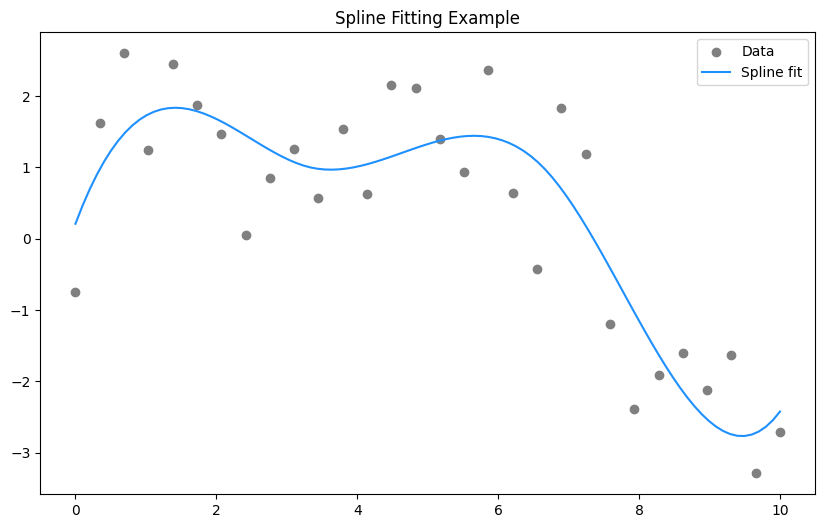

In [ ]:
# Creating the pipeline with SplineTransformer and LinearRegression
spline_pipeline = Pipeline([
    ('spline', SplineTransformer(n_knots=4, degree=3)),
    ('linear_regression', LinearRegression())
])

# Fitting the pipeline to the data
spline_pipeline.fit(X, y)

# Generating a range of values for plotting the spline
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_spline = spline_pipeline.predict(X_plot)

# Plotting the original data and the spline fit
plt.figure(figsize=(10, 6))
plt.scatter(X, y, facecolor='gray', label='Data')
plt.plot(X_plot, y_spline, label='Spline fit', color='dodgerblue')
plt.title('Spline Fitting Example')
plt.legend()
plt.show()

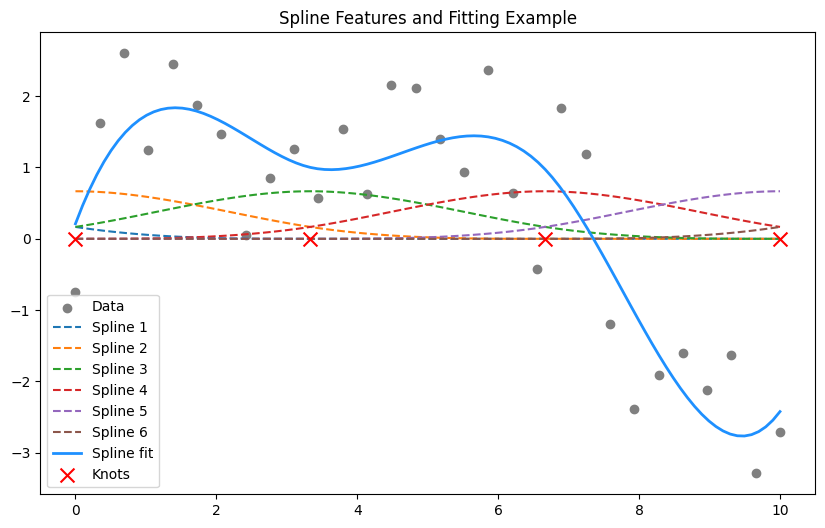

In [ ]:
# Extracting the spline transformer from the pipeline
spline_transformer = spline_pipeline.named_steps['spline']
X_splines = spline_transformer.transform(X)
# Generating a range of values for plotting the spline
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_splines = spline_transformer.transform(X_plot)
# Extracting the knot positions
knots = spline_transformer.bsplines_[0].t[3:7]

# Plotting the original data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, facecolor='gray', label='Data')

# Plotting the splines
for i in range(X_splines.shape[1]):
    plt.plot(X_plot, X_plot_splines[:, i], label=f'Spline {i+1}', linestyle='--')

# Plotting the spline fit
y_spline = spline_pipeline.predict(X_plot)
plt.plot(X_plot, y_spline, label='Spline fit', color='dodgerblue', linewidth=2)


# Adding markers at the knot positions
plt.scatter(knots, np.zeros_like(knots), color='red', marker='x', s=100, label='Knots', zorder=5)

plt.title('Spline Features and Fitting Example')
plt.legend()
plt.show()

## Smoothing Splines

Smoothing splines are particularly useful in situations where you want to fit a curve through data points in a way that balances the fit's closeness to the data points against the smoothness of the fit. In other words, we want to fit a curve that:  

- Minimizes Residual Squared Error,
- Is Smooth

$$
\sum_{i=1}^n(y_i - g(x_i))^2 + \lambda \int (g^{(m)}(t))^2 dt
$$
where $\lambda \geq 0$ is a *tuning parameter* and $g^{(m)}$ is the $m$-th derivative

The function $g(x)$ that minimizes this objective has special properties:

- It is a piecewise polynomial of degree $2m-1$,
- It has knots at $x_1, x_2, \cdots, x_n$, and
- In the region outside the knots at the extremes, it is a polynomial of degree $m-1$.


**Think About:** How does $\lambda$ control the bias-variance tradeoff of the smoothing spline?


**Think About:** What are the limits of the integral defining the objective?

In order to fit a smoothing spline in Python, we use `LinearGAM()` function in the `pygam` library. We start with generating data as follows:


For $ x \in [0, 10]$:

$$
y = \sin(0.5x) \times \sin(x) + 0.1\epsilon
$$
where $\epsilon\sim N(0,1)$.

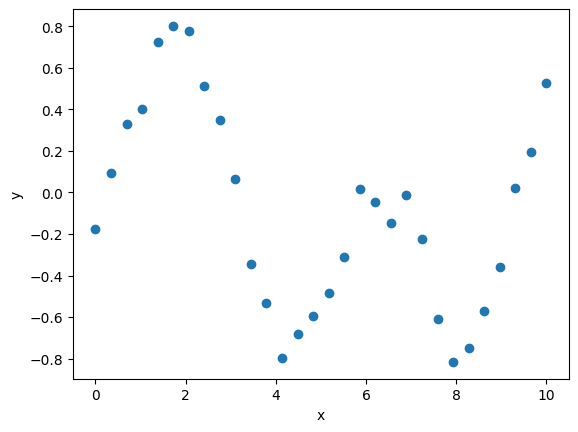

In [ ]:
np.random.seed(100)
x = np.linspace(0, 10, 30)
y = np.sin(0.5*x)*np.sin(x)+0.1*np.random.randn(30)

plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In `pyGAM`, we can specify the spline terms by `s()`in the basis functional form. [Documentation](https://pygam.readthedocs.io/en/latest/api/api.html#spline-term).

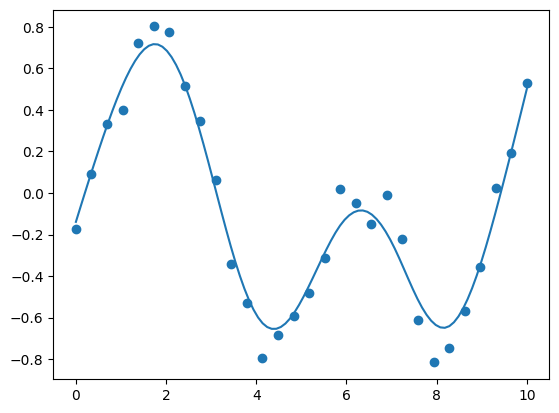

In [ ]:
# Reshaping x to be a 2D array
X = x.reshape(-1, 1)

gam = LinearGAM(s(0, lam=0.6, spline_order=3)).fit(X, y)
XX = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.scatter(x, y)
plt.plot(XX, gam.predict(XX), label=f'$\lambda$={0.6}')
plt.show()

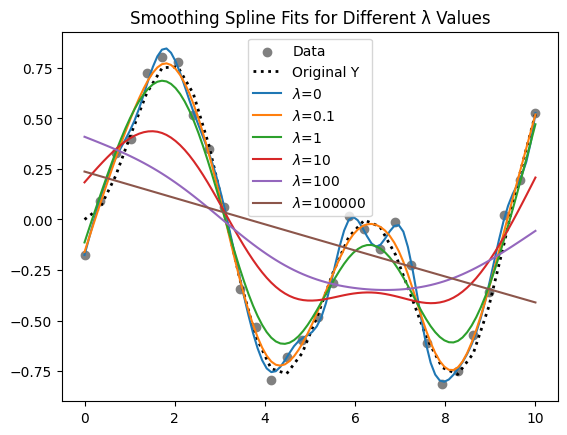

In [ ]:
# Lambda values to try
lambda_values = [0, 0.1, 1, 10, 100, 100000]

# Plotting the original data
plt.scatter(X, y, facecolor='gray', label='Data')

# Fitting a model for lambda=0 and checking coefficients
gam_zero_lambda = LinearGAM(s(0, lam=0)).fit(X, y)

# Predicting on original X values for lambda=0
y_pred_zero_lambda = gam_zero_lambda.predict(X)
plt.plot(X, np.sin(0.5 * x) * np.sin(x), label='Original Y', color='black', ls=':', lw=2)

# Fitting a model and plotting for each non-zero lambda
for lam in lambda_values:
    gam = LinearGAM(s(0, lam=lam)).fit(X, y)
    XX = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    plt.plot(XX, gam.predict(XX), label=f'$\lambda$={lam}')

plt.title('Smoothing Spline Fits for Different λ Values')
plt.legend()
plt.show()


**Think About:** How would you measure bias-variance for this family?

## Generalized Additive Models ([GAMs](https://en.wikipedia.org/wiki/Generalized_additive_model))


GAMs extend the multiple linear regression model
$$
y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip} + \epsilon_i,
$$
to allow non-linear relationships between each feature and the response by replacing each linear compontent $\beta_j x_{ij}$ with a smooth non-linear function $f_j(x_{ij})$.
$$
g(x_i) = \beta_0 + f_1(x_{i1}) + f_2 (x_{i2}) + \cdots + f_p (x_{ip}) + \epsilon_i,
$$

$g(x_i)$ is indeed a linear combination of the smooth functions $f_j(x_{ij})$, but it's important to note that the "linearity" here refers to the linearity in the parameters (coefficients of the spline basis functions), not necessarily linearity in the relationship between predictors and the response variable. The model is "additive" because it sums up the effects of each predictor, allowing for flexible, non-linear relationships to be captured through the smooth functions $f_j$.

In [ ]:
# Dataset URL
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

# Column names for the dataset
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin', 'Car Name']

# Load the dataset
df = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values="?")

# Dropping rows with missing values for simplicity
df.dropna(inplace=True)

# Drop 'Car Name' column as it's not needed for this example
df.drop(columns=['Car Name'], inplace=True)

# Convert "Origin" into a categorical variable
df['Origin'] = df['Origin'].astype('category')

df.head()

<ipython-input-12-15a2f4f7ec10>:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values="?")


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [ ]:
X = df.drop('MPG', axis=1).values
y = df['MPG'].values

In `pyGAM`, we can specify the basis functional form using terms:
- `l()`: linear terms
- `s()`: spline terms
- `f()`: factor terms
- `te()`: tensor products
- `intercept`: included by default

In the example below, we fit a spline term on feature 0 and feature 1, and a factor term on feature -1 (last column).

In [ ]:
# fit the model
gam = LinearGAM(s(feature=0, n_splines=20) + s(feature=1, n_splines=20) + f(feature=-1))
gam.fit(X, y)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + f(-1) + intercept, 
   tol=0.0001, verbose=False)

In [ ]:
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      17.314
Link Function:                     IdentityLink Log Likelihood:                                  -1455.676
Number of Samples:                          392 AIC:                                             2947.9799
                                                AICc:                                            2949.8781
                                                GCV:                                               17.2341
                                                Scale:                                             15.8696
                                                Pseudo R-Squared:                                   0.7504
Feature Function                  Lam

<ipython-input-15-dec6a6acdaaa>:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


**Think About:** How to choose the best $\lambda$?

Check [here](https://pygam.readthedocs.io/en/latest/api/lineargam.html) for the documentation and [here](https://pygam.readthedocs.io/en/latest/notebooks/quick_start.html) for the tutorial on **Automatic model tuning**. It selects the model with the lowest **generalized cross-validation (GCV)** score.

In [ ]:
lam = np.logspace(-3, 3, 11)
lams = [lam] * 3
gam.gridsearch(X, y, lam=lams)

100% (1331 of 1331) |####################| Elapsed Time: 0:00:56 Time:  0:00:56


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + f(-1) + intercept, 
   tol=0.0001, verbose=False)

In [ ]:
print(f'Optimal lambda: {gam.lam}')


Optimal lambda: [[15.848931924611142], [1.0], [15.848931924611142]]


### GAMs for Classification
Recalling the usual logistic regression model
$$
\log(\frac{p(X)}{1-P(X)}) =  \beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + \cdots + \beta_p X_{ip} + \epsilon_i,
$$
GAMs can also, analogously, extend the logistic regression model to capture non-linear relationships:
$$
\log(\frac{p(X)}{1-P(X)}) = \beta_0 + f_1(x_{i1}) + f_2 (x_{i2}) + \cdots + f_p (x_{ip}) + \epsilon_i,
$$

For the classification problem, we will use the `LogisticGAM `function from `pygam` package with the `breast_cancer` dataset. The target variable is whether the tumor of malignant (0) or benign (1), and the features are several measurements of the tumor.

In [ ]:
# URL for the Breast Cancer dataset (UCI Machine Learning Repository)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
# Column names for the dataset
column_names = ["ID", "Diagnosis"] + [f"Feature_{i}" for i in range(1, 31)]
df = pd.read_csv(url, header=None, names=column_names)

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit and transform the 'Diagnosis' column
# M stands for Malignant
# B stands for Benign
df['Diagnosis'] = label_encoder.fit_transform(df['Diagnosis'])


df.head()

,ID,Diagnosis,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,...,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Feature_29,Feature_30
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X = df.drop('Diagnosis', axis=1).values
y = df['Diagnosis'].values

# Fit a LogisticGAM with default settings as a starting point
gam = LogisticGAM(s(0) + s(1)).fit(X, y)

In [ ]:
gam.accuracy(X, y)

0.8840070298769771

In [ ]:
gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                      6.9882
Link Function:                        LogitLink Log Likelihood:                                  -163.5133
Number of Samples:                          569 AIC:                                              341.0029
                                                AICc:                                             341.2593
                                                UBRE:                                               2.6091
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.5648
Feature Function                  Lam

<ipython-input-21-dec6a6acdaaa>:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


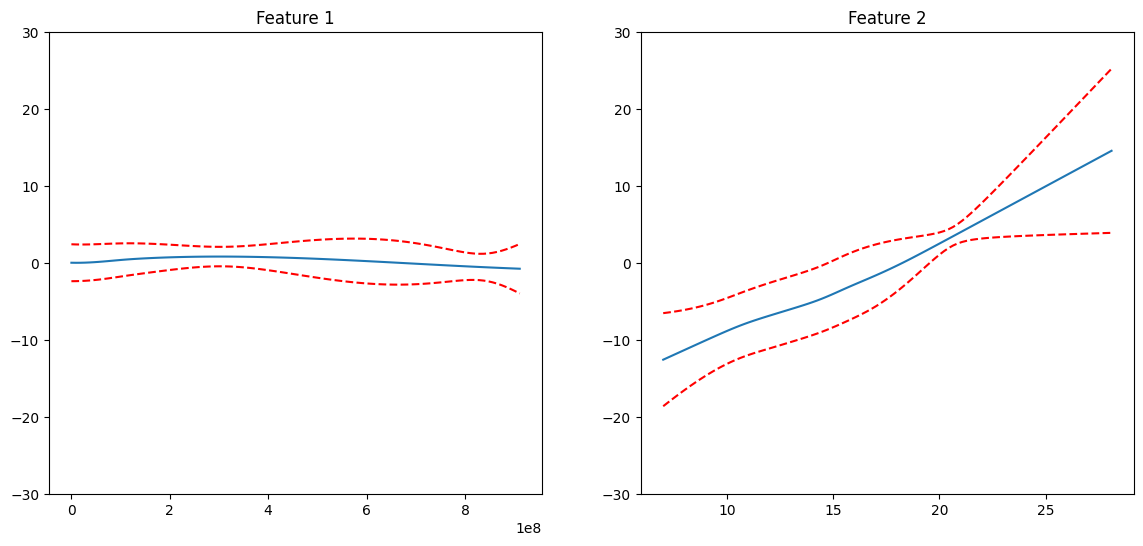

In [ ]:
# plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
titles = ['Feature 1', 'Feature 2']
for i, ax in enumerate(axs):
    # create a nice grid of X data
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax.set_ylim(-30,30)
    ax.set_title(titles[i])

plt.show()

# Group Work (30 points)

## Question 1 (6 Points)

In class, we mentioned that one can perform piecewise constant regression by appropriately modifying the design matrix to a sparse 1, 0 matrix.

For the input vector $X$ and knots at $x = 3$ and $x = 6$:
$$
X=
\begin{bmatrix}
  1\\
  2\\
  4\\
  6\\
  7\\
  9
\end{bmatrix}
\longrightarrow
\begin{bmatrix}
  1 & 0 & 0 \\  
  1 & 0 & 0 \\  
  0 & 1 & 0 \\  
  0 & 0 & 1 \\  
  0 & 0 & 1 \\  
  0 & 0 & 1
\end{bmatrix}
$$
where the the columns are obtained as $1(X < 3), 1(3 \leq X < 6), 1(6 \leq X)$.

Implement a function that takes in a vector X and returns the correct sparse feature matrix.

In [8]:
def piecewise_constant_design_matrix(X: np.ndarray, knots: np.ndarray) -> np.ndarray:
    """
    Constructs a design matrix for piecewise constant regression with disjoint bins.

    Parameters:
        X (np.ndarray): 1D array of predictor values.
        knots (np.ndarray): 1D array of knot positions (sorted).

    Returns:
        np.ndarray: Design matrix where each column corresponds to an interval
                    between consecutive knots, with an additional column for X < min(knots)
                    and another column for X >= max(knots).
    """
    X = X.reshape(-1, 1)  # Ensure X is a column vector
    knots = np.sort(knots)  # Ensure knots are sorted

    # Define regions: First region before the first knot, intermediate intervals, and last region
    ### IMPLEMENT HERE
    X = X.reshape(-1, 1)  # Ensure X is a column vector
    knots = np.sort(knots)  # Ensure knots are sorted

    # Initialize design matrix
    regions = (X < knots[0]).astype(int)  # First column: X < min(knots)

    # Intermediate bins
    for i in range(1, len(knots)):
        region = ((X >= knots[i-1]) & (X < knots[i])).astype(int)
        regions = np.hstack((regions, region))

    # Last column: X >= max(knots)
    regions = np.hstack((regions, (X >= knots[-1]).astype(int)))

    return regions

In [10]:
### DO NOT EDIT

# generate random X vector with 1000 entries between random lower and upper
np.random.seed(503)
n_samples = 1000
upper = np.random.uniform(0, 100)
lower = np.random.uniform(0, upper)
x = np.random.uniform(lower, upper, n_samples)
X = x.reshape(-1, 1)

# random knots between upper and lower
n_knots = 6
knots = np.random.uniform(lower, upper, n_knots)
knots = np.sort(knots)

# generate feature matrix
X_design = piecewise_constant_design_matrix(X, knots)

# assertion test cases
assert X_design.sum() == n_samples
assert X_design.shape[0] == n_samples
assert X_design.shape[1] == n_knots + 1
assert np.all(X_design.sum(axis=1) == 1)
expected_sum = np.array([204, 129, 76, 170, 123, 270, 28])
assert np.array_equal(X_design.sum(axis=0), expected_sum)
print('All tests passed!')

All tests passed!


## Question 2 (3 points)

Now create a function that takes in $X$, $y$, and a list of knots and perfoms piecewise constant regression.

In [12]:
from math import pi
def piecewise_constant_regression(X: np.ndarray, y: np.ndarray, knots: np.ndarray) -> LinearRegression:
    """
    Performs piecewise constant regression by constructing a design matrix and fitting a linear regression model.

    Parameters:
        X (np.ndarray): 1D array of predictor values.
        y (np.ndarray): 1D array of target values.
        knots (np.ndarray): 1D array of knot positions (sorted).

    Returns:
        LinearRegression: LinearRegression object that performs piecewise linear regression.
    """
    ### IMPLEMENT HERE
    X = X.reshape(-1,1)
    design_matrix = piecewise_constant_design_matrix(X, knots)

    model = LinearRegression()
    model.fit(design_matrix, y)
    return model

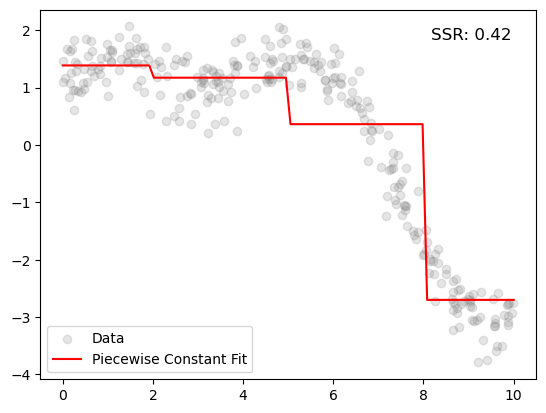

In [14]:
### DO NOT EDIT
np.random.seed(503)
n_samples = 300
x = np.random.uniform(0, 10, n_samples)  # Uniformly sampled from [0,10]
y = 2 * np.sin(0.5 * x) + np.cos(x) + np.sqrt(0.1) * np.random.randn(n_samples)
X = x.reshape(-1, 1)  # Reshaping x for the models

knots = np.array([2, 5, 8])

# Fit the piecewise constant model
model = piecewise_constant_regression(X, y, knots)

# Plot the piecewise constant fit
X_fit = np.linspace(0, 10, 100).reshape(-1, 1)
X_fit_design = piecewise_constant_design_matrix(X_fit, knots)
y_pred = model.predict(X_fit_design)
# Compute sum of squared residuals
y_pred_train = model.predict(piecewise_constant_design_matrix(X, knots))
ssr = np.mean((y - y_pred_train) ** 2)
# Scatter plot data
plt.scatter(X, y, color='gray', alpha=0.2, label="Data")
# plot fitted line
plt.plot(X_fit, model.predict(X_fit_design), label='Piecewise Constant Fit', color='red')
# add train loss in the top right corner
plt.text(0.95, 0.95, f'SSR: {ssr:.2f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', horizontalalignment='right')
plt.legend()
plt.show()

## Question 3 (2 points)

Import the NHANES datasets. Then

1. Keep the HDL in mg/DL as your target variable. Also, use the following features for predictive purposes: Gender, Age, Weight, Height, BMI, WaistSize, Household Size, and Ethnicity. You may need to refer to the docs to figure out their variable names.
*   [HDL_L](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/HDL_L.htm)
*   [DEMO_L](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.htm)
*   [BMX_L](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.htm)

2. **Please** change the variable names to be English-legible but still python variable style.

3. Drop all missing values.

In [38]:
import pandas as pd

### IMPLEMENT HERE
bmx_df = pd.read_sas('BMX_L.xpt', format = 'xport')
demo_df = pd.read_sas('DEMO_L.xpt', format = 'xport')
hdl_df = pd.read_sas('HDL_L.xpt', format = 'xport')

# inner join on SEQN
df = pd.merge(hdl_df, bmx_df, on='SEQN', how='inner')
df = pd.merge(df, demo_df, on='SEQN', how='inner')
# Select relevant columns and rename them
my_df = df[[
    'LBDHDD',      # HDL
    'RIAGENDR',    # Gender
    'RIDAGEYR',    # Age
    'BMXWT',       # Weight
    'BMXHT',       # Height
    'BMXBMI',      # BMI
    'BMXWAIST',    # Waist Size
    'DMDHHSIZ',    # Household Size
    'RIDRETH3'     # Ethnicity
]].rename(columns={
    'LBDHDD': 'HDL',
    'RIAGENDR': 'gender',
    'RIDAGEYR': 'age',
    'BMXWT': 'weight',
    'BMXHT': 'height',
    'BMXBMI': 'BMI',
    'BMXWAIST': 'waist_size',
    'DMDHHSIZ': 'household_size',
    'RIDRETH3': 'ethnicity'
})

# Drop missing values
my_df = my_df.dropna()

In [40]:
### DO NOT EDIT
assert my_df.shape == (6589, 9)

## Question 4 (4 points)

Create a Pipeline that does the following:

1. Create degree 4 spline features with 8 knots
2. Standard Scaling
3. Linear Regression

Fit the pipeline to HDL and BMI in `my_df`.

In [42]:
my_df.head()

,HDL,gender,age,weight,height,BMI,waist_size,household_size,ethnicity
0,45.0,1.0,43.0,86.9,179.5,27.0,98.3,4.0,6.0
1,60.0,1.0,66.0,101.8,174.2,33.5,114.7,2.0,3.0
2,49.0,2.0,44.0,69.4,152.9,29.7,93.5,7.0,2.0
3,46.0,1.0,34.0,90.6,173.3,30.2,106.1,3.0,1.0
4,42.0,2.0,68.0,103.5,155.9,42.6,122.0,1.0,3.0


In [44]:
pipeline = Pipeline([
   ('spline_features', SplineTransformer(n_knots=8, degree=4)),
   ('scaler', StandardScaler()),
   ('regressor', LinearRegression())
])

X = my_df[['BMI']]
y = my_df[['HDL']]
pipeline.fit(X, y)

Pipeline(steps=[('spline_features', SplineTransformer(degree=4, n_knots=8)),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(


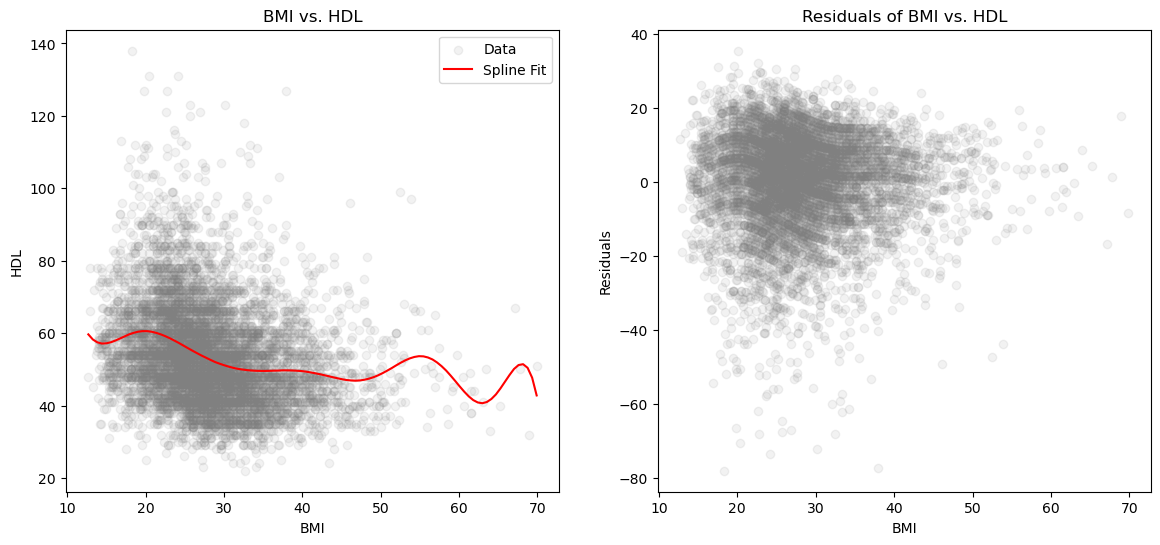

Linear Regression Coefficients: [-2.61840541e+11 -7.33114737e+12 -2.42205969e+13 -2.56769909e+13
 -2.56297922e+13 -2.15980844e+13 -1.21098607e+13 -5.79098912e+12
 -3.18582805e+12 -1.19287150e+12 -7.77360220e+10]


In [46]:
### DO NOT EDIT
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
titles = ['BMI vs. HDL', 'Residuals of BMI vs. HDL']
axs[0].scatter(X, y, color='gray', alpha=0.1, label="Data")
x_linspace = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
axs[0].plot(x_linspace, pipeline.predict(x_linspace), label='Spline Fit', color='red')
axs[0].set_xlabel('BMI')
axs[0].set_ylabel('HDL')
axs[0].set_title(titles[0])
axs[0].legend()
axs[1].scatter(my_df['BMI'], pipeline.predict(X) - y, color='gray', alpha=0.1)
axs[1].set_xlabel('BMI')
axs[1].set_ylabel('Residuals')
axs[1].set_title(titles[1])

plt.show()
print(f'Linear Regression Coefficients: {pipeline.named_steps["regressor"].coef_[0]}')

## Question 5 (4 points)

We want to decide how many knots and the degree of the spline that we should use. Working with all the predictive features, use [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) to find the optimal parameter values.

Use 10-fold CV with MSE as the metric of choice. Perform the search over the following parameters:

1.   degree: 2, 3, 4
2.   number of knots: 4, 8, 16, 32

Your GridSearchCV object should be called `grid_search` in order to pass the test cases.

In [52]:
### IMPLEMENT HERE (Use Q4 to get a start.)

pipeline = Pipeline([
   ('spline_features', SplineTransformer()),
   ('scaler', StandardScaler()),
   ('regressor', LinearRegression())
])

# Define parameter grid
param_grid = {
   'spline_features__degree': [2, 3, 4],
   'spline_features__n_knots': [4, 8, 16, 32]
}

# Create GridSearchCV object
grid_search = GridSearchCV(
   pipeline,
   param_grid,
   cv=10,
   scoring='neg_mean_squared_error',
   n_jobs=-1
)

# Fit with all predictive features
X = my_df[['BMI', 'gender', 'age', 'weight', 'height', 'waist_size', 'household_size', 'ethnicity']]
y = my_df['HDL']

grid_search.fit(X, y)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('spline_features', SplineTransformer()),
                                       ('scaler', StandardScaler()),
                                       ('regressor', LinearRegression())]),
             n_jobs=-1,
             param_grid={'spline_features__degree': [2, 3, 4],
                         'spline_features__n_knots': [4, 8, 16, 32]},
             scoring='neg_mean_squared_error')

In [54]:
### DO NOT EDIT
expected = {'spline_features__degree': 2, 'spline_features__n_knots': 4}
assert grid_search.best_params_ == expected
assert grid_search.best_estimator_.named_steps["regressor"].coef_.shape == (8 * (4+2-1),)

## Question 6 (3 points)

Import the `default` dataset from `pygam.datasets`. See [documentation](https://pygam.readthedocs.io/en/latest/) and [GitHub](https://github.com/dswah/pyGAM/blob/master/pygam/datasets/load_datasets.py). Create an 80-20 train test split with random state 503.

In [56]:
from pygam.datasets import default
from sklearn.model_selection import train_test_split

### IMPLEMENT HERE
X, y = default()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=503)

## Question 7 (5 points)

Fit a Logistic GAM with factor term on the first variable and splines on the rest. Perform gridsearch over the penalizing values of $\lambda$ using the `gridsearch` method of the gam object.

**Note**: If no parameters are specified, lam=np.logspace(-3, 3, 11) is used. This results in 11 points, placed diagonally across lam space.

In [60]:
### IMPLEMENT HERE
gam = LogisticGAM(f(0) + s(1) + s(2))
# lam = np.logspace(-3, 3, 11)
# lams = [lam] * 3
gam.gridsearch(X_train, y_train)

100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:010:00


LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=f(0) + s(1) + s(2) + intercept, tol=0.0001, verbose=False)

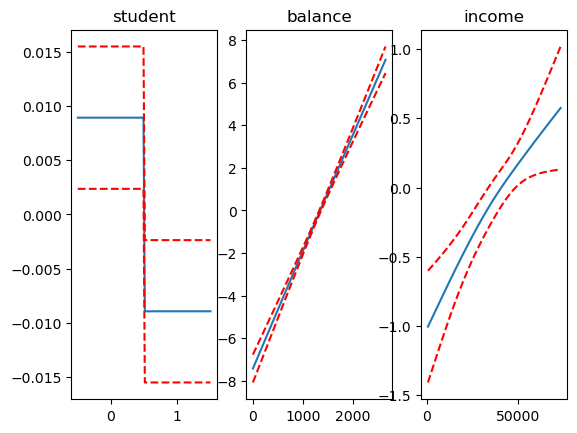

In [62]:
### DO NOT EDIT
fig, axs = plt.subplots(1, 3)
titles = ['student', 'balance', 'income']

for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, width=.95)

    ax.plot(XX[:, i], pdep)
    ax.plot(XX[:, i], confi, c='r', ls='--')
    ax.set_title(titles[i])

## Question 8 (3 points)

Comment on the partial dependance graphs.

**ANSWER**:
- Student: Being as a student (student=1) has a negative effect on the default probability of risk, indicating that students tend to have higher probability of risk than non-students.
- Balance: It seems that there is a positive linear relationship between balance and default probability of risk. The narrow confidence interval bands indicate the model is quite certain about this relationship
- Income: The relationship between income and risk are non-linear. Wider confidence intervals at both low and high income extremes indicate less data available in those regions